# GFP DMS cleanup

- Parse mutant strings like "K3R" or "K3A:V65A"
- Count mutations and filter to ≤2
- Reconstruct sequences from WT and validate
- Deduplicate repeats; add normalized fitness; save outputs

In [1]:
import os, re, random
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

RANDOM_SEED = 1337
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# File paths (adjust as needed)
REF_PATH = "../data/ref_gfp.csv"
DMS_PATH = "../data/GFP_AEQVI_Sarkisyan_2016.csv"

OUT_DIR = "../data"
os.makedirs(OUT_DIR, exist_ok=True)

AA = set("ACDEFGHIKLMNPQRSTVWY")  # standard 20 AAs

Load WT and DMS

In [2]:
# Load WT
ref_df = pd.read_csv(REF_PATH)
assert "target_seq" in ref_df.columns, "ref_gfp.csv must have a 'target_seq' column"
assert len(ref_df) == 1, "ref_gfp.csv should have exactly one row"
WT = ref_df.iloc[0]["target_seq"].strip().upper()
L = len(WT)
print("WT len:", L, "| WT head:", WT[:60] + ("..." if L>60 else ""))

# Load DMS
dms_raw = pd.read_csv(DMS_PATH)

mut_col = "mutant"
seq_col = "mutated_sequence"
fit_col = "DMS_score"

dms = dms_raw.copy()
dms[seq_col] = dms[seq_col].astype(str).str.strip().str.upper()
dms[mut_col] = dms[mut_col].astype(str).str.strip().str.upper()
dms = dms[~dms[fit_col].isna()].copy()

WT len: 238 | WT head: MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTL...


Parse "mutant" string

In [3]:
# Regex for one mutation: e.g., K3R  (from AA)(1-based index)(to AA)
MUT_RE = re.compile(r'([ACDEFGHIKLMNPQRSTVWY])(\d+)([ACDEFGHIKLMNPQRSTVWY])')

def split_mut_str(mut: str) -> List[str]:
    """
    Split a compound mutation string into items like ["K3R", "V65A"].
    Accept separators ':', ';', ',', whitespace.
    Handle WT markers like "" / "WT" / "-" / "NONE" as 0 mutations.
    """
    if mut in ("", "WT", "W T", "-", "NONE", "NA", "N/A"):
        return []
    parts = re.split(r'[:;, \t]+', mut)
    return [p for p in parts if p]

def parse_mutation_item(item: str) -> Optional[Tuple[str, int, str]]:
    """
    Parse a single item e.g. 'K3R' → ('K', 3, 'R'), validate AA letters.
    Return None if not matched.
    """
    m = MUT_RE.fullmatch(item)
    if not m:
        return None
    frm, pos, to = m.group(1), int(m.group(2)), m.group(3)
    return (frm, pos, to)

def parse_mutation_string(mut: str) -> Optional[List[Tuple[str, int, str]]]:
    """
    Convert 'K3A:V65A' → [('K',3,'A'), ('V',65,'A')].
    Returns None if any item fails to parse.
    """
    items = split_mut_str(mut)
    out = []
    for item in items:
        parsed = parse_mutation_item(item)
        if parsed is None:
            return None
        out.append(parsed)
    # sort by position (useful for canonicalization)
    out.sort(key=lambda x: x[1])
    return out


Recontruct sequence (check)

In [4]:
def apply_mutations(wt: str, muts: List[Tuple[str, int, str]]) -> Optional[str]:
    """
    Apply list of (fromAA, pos1based, toAA) to the WT sequence.
    Validate that WT[pos-1] == fromAA. Return None if validation fails.
    """
    s = list(wt)
    for frm, pos, to in muts:
        if pos < 1 or pos > len(s):
            return None
        if s[pos-1] != frm:  # validation: fromAA must match WT residue
            return None
        if to not in AA:
            return None
        s[pos-1] = to
    return "".join(s)

def canonical_mut_string(muts: List[Tuple[str, int, str]]) -> str:
    """Return a canonical string like 'K3R:V65A' sorted by position."""
    return ":".join(f"{frm}{pos}{to}" for (frm,pos,to) in muts)

# Parse & reconstruct
rows = []
bad_rows = 0

for idx, row in dms.iterrows():
    mut_str = str(row[mut_col]).strip().upper()
    muts = parse_mutation_string(mut_str)
    if muts is None:
        bad_rows += 1
        continue
    seq_rec = apply_mutations(WT, muts)
    if seq_rec is None:
        # fallback: if dataset has marked WT explicitly and muts==[]
        if mut_str in ("", "WT", "W T", "-", "NONE", "NA", "N/A"):
            seq_rec = WT
        else:
            bad_rows += 1
            continue

    # If there is a sequence column, optionally validate consistency
    if seq_col:
        seq_given = row[seq_col]
        if isinstance(seq_given, str) and len(seq_given) == len(WT):
            # If inconsistent, prefer reconstructed; but we could flag it
            pass

    rows.append({
        "sequence": seq_rec,
        "mutant_canonical": canonical_mut_string(muts),
        "n_mut": len(muts),
        "fitness_raw": float(row[fit_col]),
    })

clean = pd.DataFrame(rows)
print("Parsed rows:", len(clean), "| Bad rows skipped:", bad_rows)
clean.head(5)


Parsed rows: 51714 | Bad rows skipped: 0


,sequence,mutant_canonical,n_mut,fitness_raw
0,MSRGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,K3R:V55A:Q94R:A110T:D117G:M153K:D216A,7,1.301030
1,MSQGEELFTGVVPILAELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,K3Q:V16A:I167T:L195Q,4,3.137350
2,MSQGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,K3Q:Y143C:N164D:S205P:A227T,5,1.553913
3,MSQGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,K3Q:Y143N:V193A,3,3.404237
4,MSRGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,K3R,1,3.738586


Filter to <= 2 mutants

In [5]:
le2 = clean[clean["n_mut"] <= 2].copy()
print("≤2-mut rows:", len(le2))
print(le2["n_mut"].value_counts().sort_index())
le2.head(5)


≤2-mut rows: 13861
n_mut
1     1084
2    12777
Name: count, dtype: int64


,sequence,mutant_canonical,n_mut,fitness_raw
4,MSRGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,K3R,1,3.738586
13,MSRGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,K3R:D133A,2,3.716293
41,MSNGEELFTGVVPILVELDGDVNGHKFSVYGEGEGDATYGKLTLKF...,K3N:S30Y,2,3.833353
45,MSNGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,K3N:V150A,2,3.553744
48,MSQGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,K3Q,1,3.750487


Deduplicate and normalization

In [6]:
agg = (
    le2
    .groupby(["sequence", "n_mut"], as_index=False)
    .agg(
        fitness=("fitness_raw", "mean"),
        n_measurements=("fitness_raw", "count"),
    )
)

# Z-score and robust normalization
mu = agg["fitness"].mean()
sd = agg["fitness"].std(ddof=0) + 1e-8
agg["fitness_z"] = (agg["fitness"] - mu) / sd

med = agg["fitness"].median()
mad = (agg["fitness"] - med).abs().median() + 1e-8
agg["fitness_robust"] = (agg["fitness"] - med) / mad

print("After dedup:", len(agg))
agg.head(5)


After dedup: 13861


,sequence,n_mut,fitness,n_measurements,fitness_z,fitness_robust
0,MSEGEELFTGVVPFLVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,2,3.259355,1,-0.135109,-2.931214
1,MSEGEELFTGVVPILVELDGDINGHKFSVSGEGEGDATYGKLTLKF...,2,3.542828,1,0.276839,-0.484781
2,MSEGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLALKF...,2,3.847248,1,0.719229,2.142434
3,MSEGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,2,3.711611,1,0.522119,0.971857
4,MSEGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,2,3.542296,1,0.276066,-0.489370


Save output

In [7]:
out_all = os.path.join(OUT_DIR, "dms_all.csv")
out_le2 = os.path.join(OUT_DIR, "dms_le2.csv")

clean.to_csv(out_all, index=False)   # all parsed (any n_mut)
agg.to_csv(out_le2, index=False)     # ≤2 mutants, deduped + normalized

print("Wrote:")
print(" -", out_all)
print(" -", out_le2)


Wrote:
 - ../data\dms_all.csv
 - ../data\dms_le2.csv


Sanity

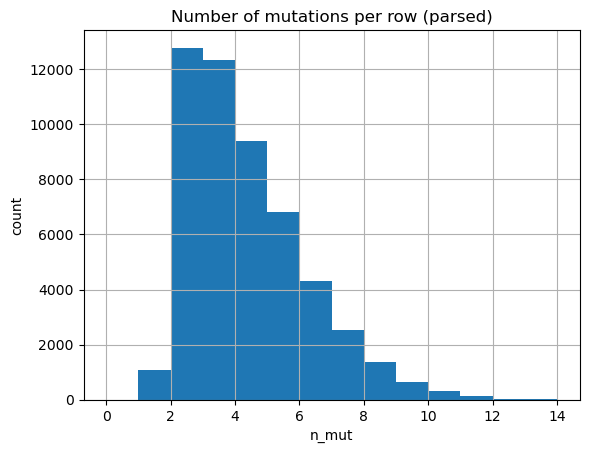

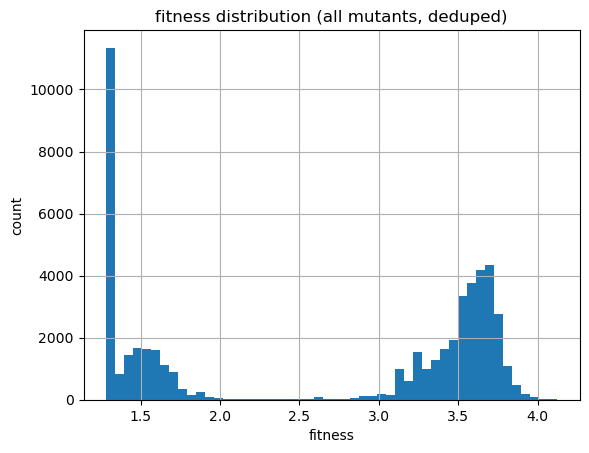

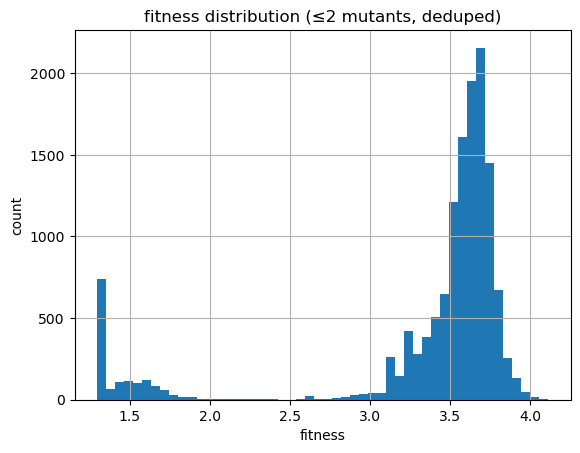

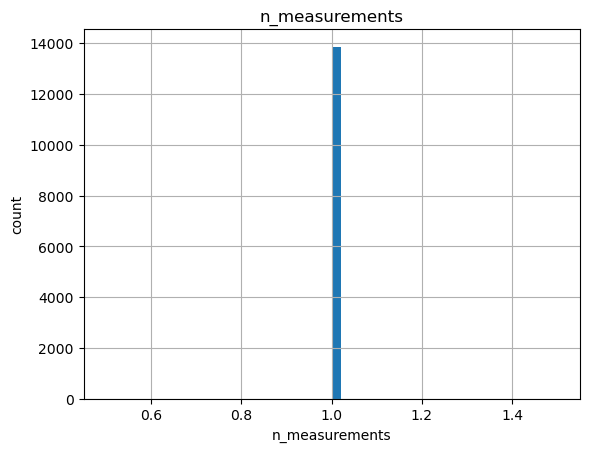

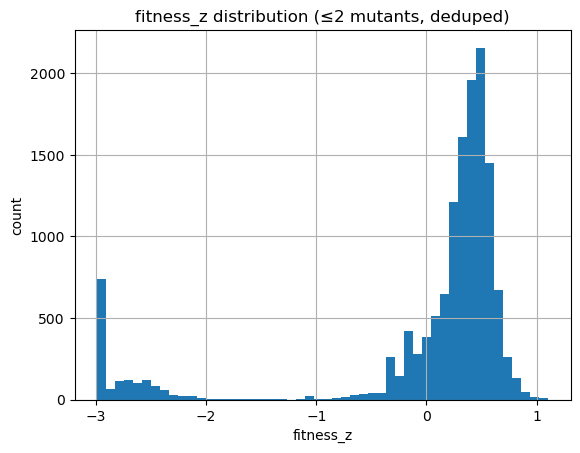

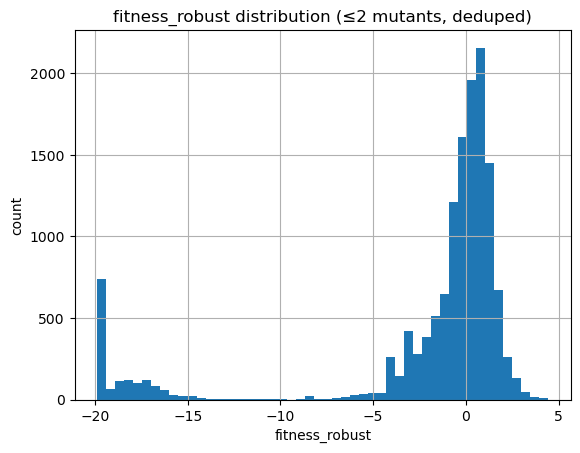

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
clean["n_mut"].hist(bins=range(0, min(15, clean["n_mut"].max()+2)))
plt.title("Number of mutations per row (parsed)")
plt.xlabel("n_mut"); plt.ylabel("count")
plt.show()

plt.figure()
clean["fitness_raw"].hist(bins=50)
plt.title("fitness distribution (all mutants, deduped)")
plt.xlabel("fitness"); plt.ylabel("count")
plt.show()

plt.figure()
agg["fitness"].hist(bins=50)
plt.title("fitness distribution (≤2 mutants, deduped)")
plt.xlabel("fitness"); plt.ylabel("count")
plt.show()

plt.figure()
agg["fitness_z"].hist(bins=50)
plt.title("fitness_z distribution (≤2 mutants, deduped)")
plt.xlabel("fitness_z"); plt.ylabel("count")
plt.show()

plt.figure()
agg["fitness_robust"].hist(bins=50)
plt.title("fitness_robust distribution (≤2 mutants, deduped)")
plt.xlabel("fitness_robust"); plt.ylabel("count")
plt.show()
